# Lucas-Kanade Optical Flow Demo

Demonstrates the Lucas-Kanade local optical flow method, including the per-pixel
reliability map (minimum eigenvalue of the structure tensor).

Lucas-Kanade is a **local** method: it estimates flow at each pixel by solving a
weighted least-squares problem over a Gaussian window. The minimum eigenvalue of
the structure tensor indicates how reliable the estimate is at each pixel (the
Shi-Tomasi "good features to track" criterion).

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import os
import time

from flow_fast import estimate_flow, flow_to_color, plot_flow, flow_angular_error
from optical_flow.io.flo_io import read_flow_file
from optical_flow.methods.lk import LKOpticalFlow
from optical_flow.utils.image_processing import scale_image, structure_texture_decomposition_rof

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['figure.dpi'] = 100

## 1. Load Test Images

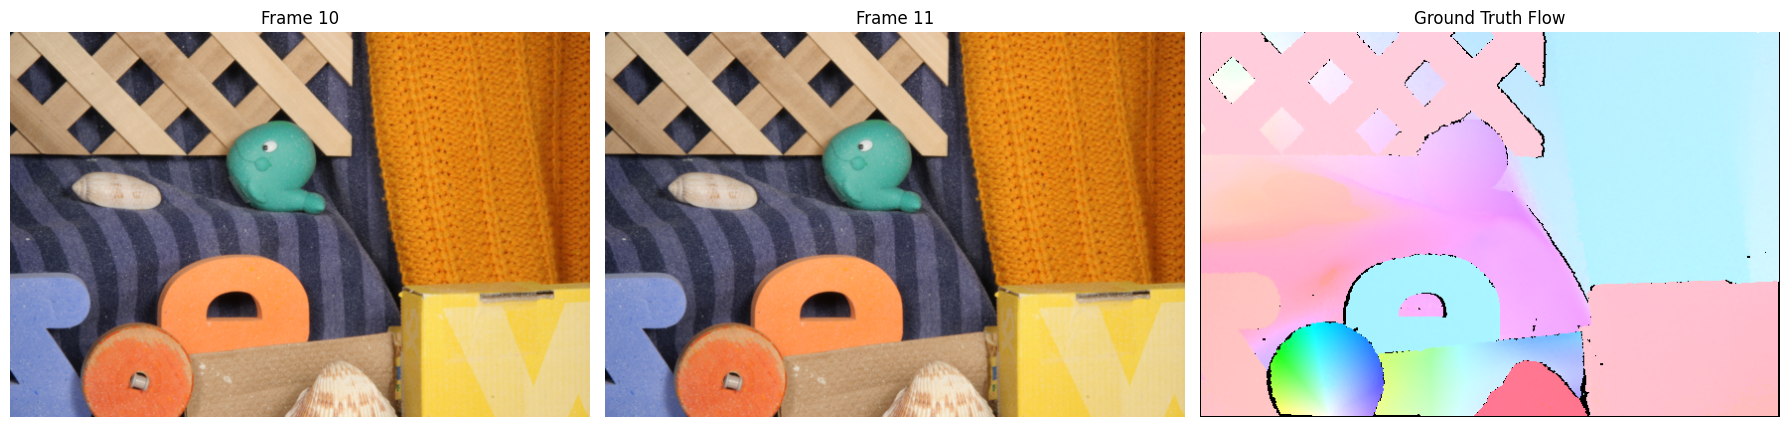

In [14]:
data_dir = os.path.join('..', 'data')
im1, im2, tu, tv = read_flow_file('RubberWhale', 10, data_dir=data_dir)
gt_flow = np.stack([tu, tv], axis=2)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(im1.astype(np.uint8))
axes[0].set_title('Frame 10')
axes[0].axis('off')
axes[1].imshow(im2.astype(np.uint8))
axes[1].set_title('Frame 11')
axes[1].axis('off')
plot_flow(gt_flow, style='color', ax=axes[2])
axes[2].set_title('Ground Truth Flow')
plt.tight_layout()
plt.show()

## 2. Run Lucas-Kanade with Reliability Map

Using the class directly to access the reliability map (minimum eigenvalue of the
structure tensor at each pixel).

In [15]:
# Run LK via high-level API
print('Running Lucas-Kanade...')
t0 = time.time()
window_size = 3
uv_lk = estimate_flow(im1, im2, method='lk', params={'window_size': window_size})
elapsed = time.time() - t0

aae, std_ae, aepe = flow_angular_error(tu, tv, uv_lk[:,:,0], uv_lk[:,:,1])
print(f'AAE: {aae:.2f} deg, AEPE: {aepe:.3f} px, Time: {elapsed:.1f}s')

# Now run via the class directly to get the reliability map
lk = LKOpticalFlow()
lk.texture = True
lk.median_filter_size = [5, 5]

# Prepare grayscale images
gray1 = np.clip(np.floor(im1 + 0.5), 0, 255).astype(np.uint8)
gray1 = (0.2989 * gray1[:,:,0].astype(float) +
         0.5870 * gray1[:,:,1].astype(float) +
         0.1140 * gray1[:,:,2].astype(float))
gray1 = np.floor(gray1 + 0.5)
gray2 = np.clip(np.floor(im2 + 0.5), 0, 255).astype(np.uint8)
gray2 = (0.2989 * gray2[:,:,0].astype(float) +
         0.5870 * gray2[:,:,1].astype(float) +
         0.1140 * gray2[:,:,2].astype(float))
gray2 = np.floor(gray2 + 0.5)

images = structure_texture_decomposition_rof(np.stack([gray1, gray2], axis=2))
lk.images = images
uv_lk = lk.compute_flow()

reliability = lk.reliability
print(f'\nReliability map shape: {reliability.shape}')
print(f'Reliability range: [{reliability.min():.4f}, {reliability.max():.4f}]')

Running Lucas-Kanade...
AAE: 3.60 deg, AEPE: 0.112 px, Time: 2.3s

Reliability map shape: (388, 584)
Reliability range: [6.6301, 1348.5665]


## 3. Visualize Flow and Reliability

The reliability map shows the minimum eigenvalue of the structure tensor.
Higher values indicate more reliable flow estimates (strong gradients in
multiple directions). Low values indicate the aperture problem (edges or
textureless regions).

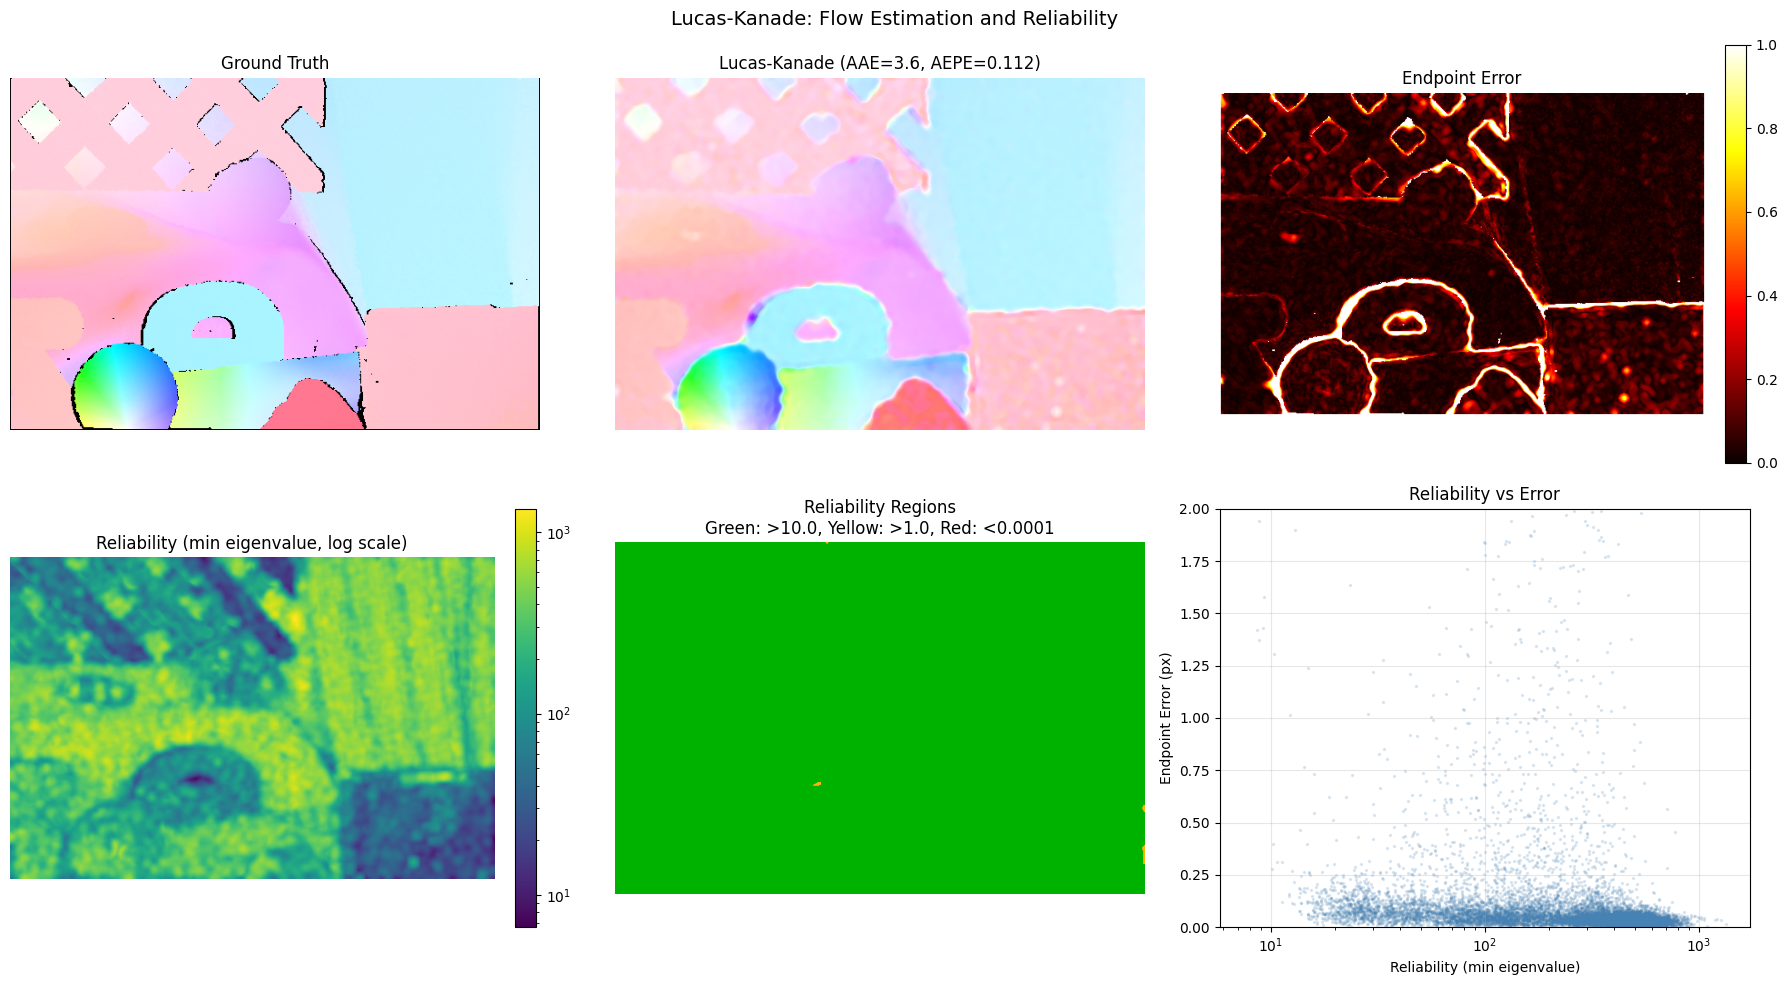

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: Ground truth, estimated flow, error map
plot_flow(gt_flow, style='color', ax=axes[0, 0])
axes[0, 0].set_title('Ground Truth')

plot_flow(uv_lk, style='color', ax=axes[0, 1])
axes[0, 1].set_title(f'Lucas-Kanade (AAE={aae:.1f}, AEPE={aepe:.3f})')

epe_map = np.sqrt((tu - uv_lk[:,:,0])**2 + (tv - uv_lk[:,:,1])**2)
im_err = axes[0, 2].imshow(epe_map, cmap='hot', vmin=0, vmax=1.0)
axes[0, 2].set_title('Endpoint Error')
axes[0, 2].axis('off')
plt.colorbar(im_err, ax=axes[0, 2], fraction=0.046, pad=0.04)

# Row 2: Reliability map, thresholded reliability, reliability vs error
im_rel = axes[1, 0].imshow(reliability, cmap='viridis', norm=LogNorm())
axes[1, 0].set_title('Reliability (min eigenvalue, log scale)')
axes[1, 0].axis('off')
plt.colorbar(im_rel, ax=axes[1, 0], fraction=0.046, pad=0.04)

# Binary reliable/unreliable at different thresholds
thresholds = [1e-4, 1.0, 10.0]
reliable_vis = np.zeros((*reliability.shape, 3))
reliable_vis[reliability > thresholds[2]] = [0, 0.7, 0]   # green = highly reliable
reliable_vis[(reliability > thresholds[1]) & (reliability <= thresholds[2])] = [1, 0.7, 0]  # yellow = moderate
reliable_vis[(reliability > thresholds[0]) & (reliability <= thresholds[1])] = [1, 0.3, 0]  # orange = marginal
reliable_vis[reliability <= thresholds[0]] = [0.8, 0, 0]   # red = unreliable
axes[1, 1].imshow(reliable_vis)
axes[1, 1].set_title(f'Reliability Regions\nGreen: >{thresholds[2]}, Yellow: >{thresholds[1]}, Red: <{thresholds[0]}')
axes[1, 1].axis('off')

# Scatter: reliability vs endpoint error
# Subsample for readability
mask = np.random.rand(*reliability.shape) < 0.05
axes[1, 2].scatter(reliability[mask], epe_map[mask], alpha=0.15, s=2, c='steelblue')
axes[1, 2].set_xlabel('Reliability (min eigenvalue)')
axes[1, 2].set_ylabel('Endpoint Error (px)')
axes[1, 2].set_xscale('log')
axes[1, 2].set_title('Reliability vs Error')
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].set_ylim(0, 2.0)

plt.suptitle('Lucas-Kanade: Flow Estimation and Reliability', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Effect of Window Size

Larger windows provide more constraints (better conditioning) but reduce spatial
resolution. Smaller windows preserve detail but are noisier.

Running LK with window_size=3...
Running LK with window_size=5...
Running LK with window_size=11...
Running LK with window_size=15...
Running LK with window_size=25...


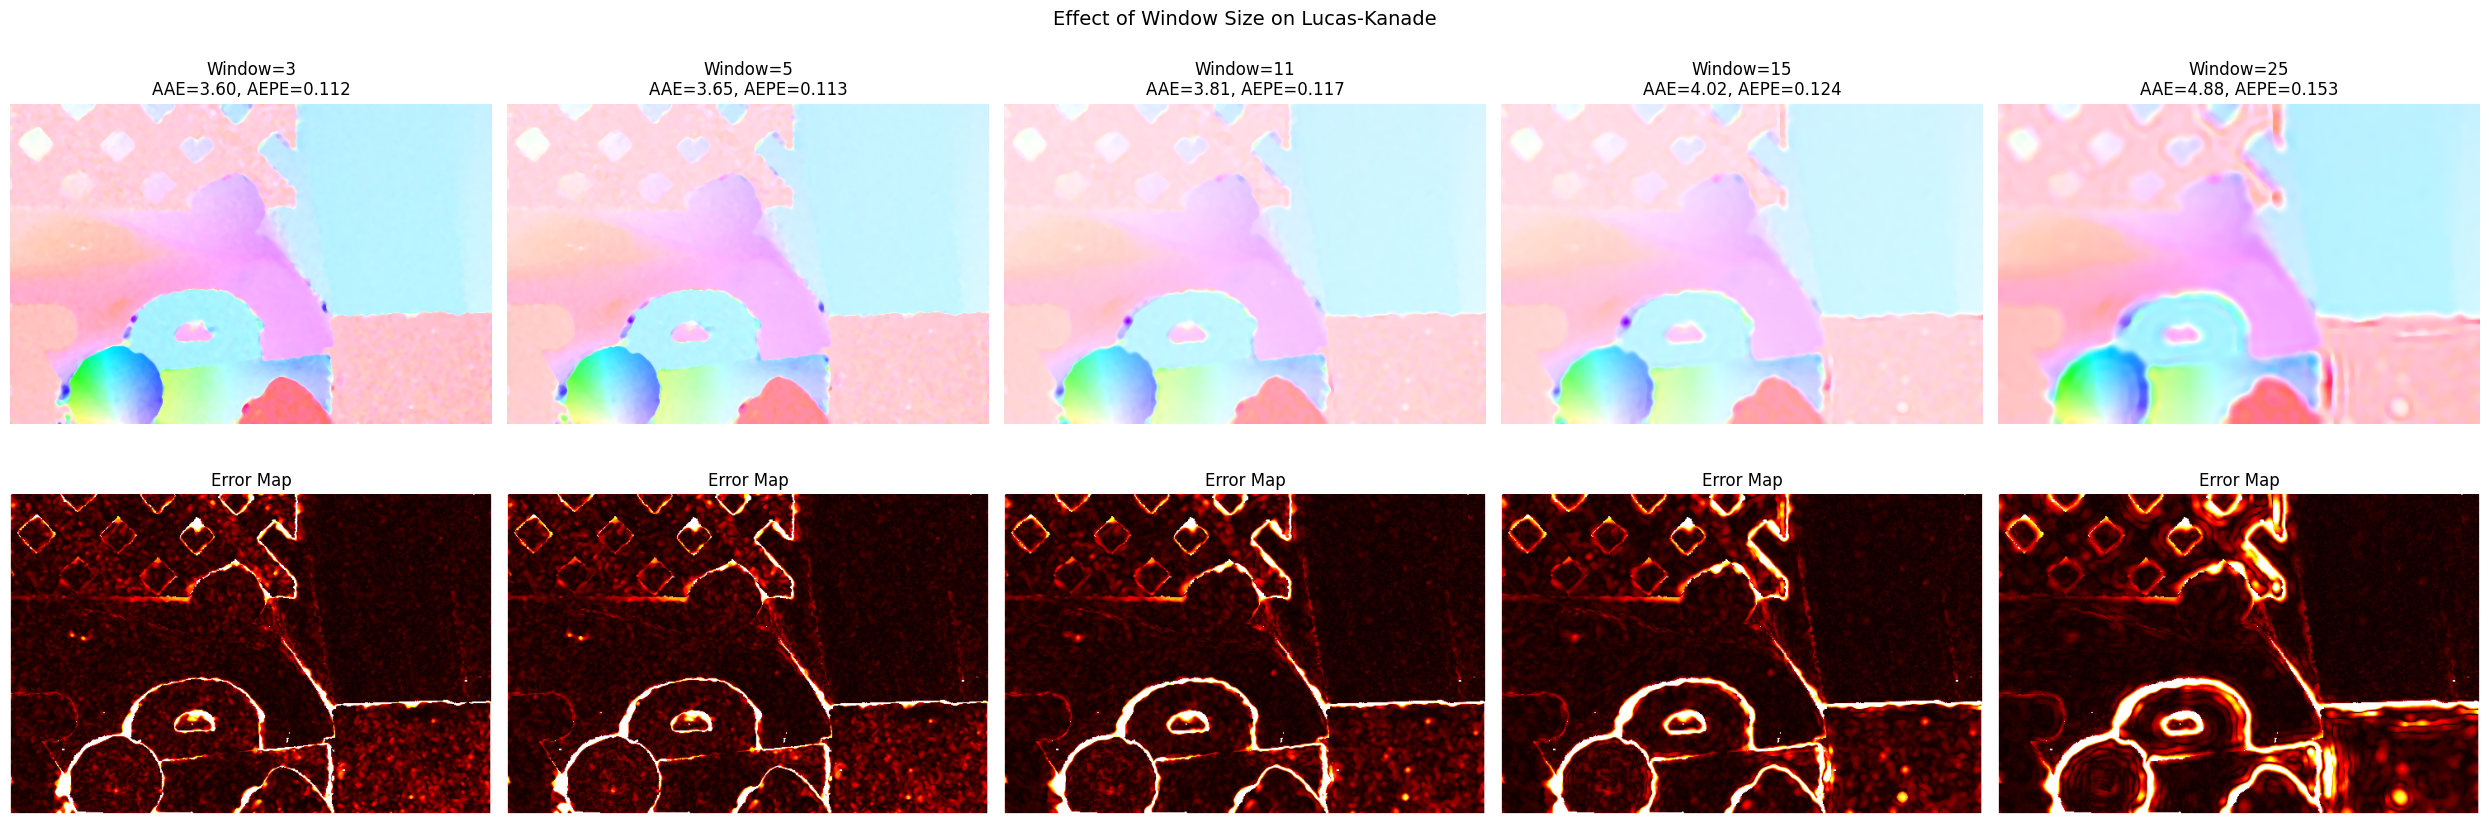

In [17]:
window_sizes = [3, 5, 11, 15, 25]

fig, axes = plt.subplots(2, len(window_sizes), figsize=(5 * len(window_sizes), 9))

for i, ws in enumerate(window_sizes):
    print(f'Running LK with window_size={ws}...')
    uv = estimate_flow(im1, im2, method='lk',
                       params={'window_size': ws})
    aae_ws, _, aepe_ws = flow_angular_error(tu, tv, uv[:,:,0], uv[:,:,1])

    plot_flow(uv, style='color', ax=axes[0, i])
    axes[0, i].set_title(f'Window={ws}\nAAE={aae_ws:.2f}, AEPE={aepe_ws:.3f}')

    epe = np.sqrt((tu - uv[:,:,0])**2 + (tv - uv[:,:,1])**2)
    axes[1, i].imshow(epe, cmap='hot', vmin=0, vmax=1.0)
    axes[1, i].set_title(f'Error Map')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Flow', fontsize=12)
axes[1, 0].set_ylabel('Endpoint Error', fontsize=12)
plt.suptitle('Effect of Window Size on Lucas-Kanade', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Comparison with Other Methods

In [19]:
methods = [
    ('lk', 'Lucas-Kanade'),
    ('hs', 'Horn-Schunck'),
    ('ba', 'Black-Anandan'),
    ('classic+nl-fast', 'Classic+NL-Fast'),
]

results = []
flows = {}

for method_name, label in methods:
    print(f'Running {label}...')
    t0 = time.time()
    uv = estimate_flow(im1, im2, method=method_name)
    elapsed = time.time() - t0
    aae_m, _, aepe_m = flow_angular_error(tu, tv, uv[:,:,0], uv[:,:,1])
    results.append({'method': label, 'aae': aae_m, 'aepe': aepe_m, 'time': elapsed})
    flows[label] = uv
    print(f'  AAE={aae_m:.2f}, AEPE={aepe_m:.3f}, Time={elapsed:.1f}s')

print(f'\n{"":=<65}')
print(f'{"Method":<25} {"AAE (deg)":>10} {"AEPE (px)":>10} {"Time (s)":>10}')
print(f'{"":-<65}')
for r in results:
    print(f'{r["method"]:<25} {r["aae"]:>10.2f} {r["aepe"]:>10.3f} {r["time"]:>10.1f}')
print(f'{"":=<65}')

Running Lucas-Kanade...
  AAE=4.02, AEPE=0.124, Time=2.2s
Running Horn-Schunck...
Pyramid level: 5
  Iteration: 1  (norm: 1.827132)
  Iteration: 2  (norm: 0.408091)
  Iteration: 3  (norm: 0.387915)
  Iteration: 4  (norm: 0.375552)
  Iteration: 5  (norm: 0.444066)
  Iteration: 6  (norm: 0.392293)
  Iteration: 7  (norm: 0.438610)
  Iteration: 8  (norm: 0.420960)
  Iteration: 9  (norm: 0.503092)
  Iteration: 10  (norm: 0.415944)
Pyramid level: 4
  Iteration: 1  (norm: 4.953433)
  Iteration: 2  (norm: 1.307437)
  Iteration: 3  (norm: 1.093496)
  Iteration: 4  (norm: 1.056351)
  Iteration: 5  (norm: 1.060962)
  Iteration: 6  (norm: 1.055713)
  Iteration: 7  (norm: 1.048700)
  Iteration: 8  (norm: 1.027467)
  Iteration: 9  (norm: 1.060394)
  Iteration: 10  (norm: 1.036694)
Pyramid level: 3
  Iteration: 1  (norm: 15.334716)
  Iteration: 2  (norm: 4.628891)
  Iteration: 3  (norm: 4.377372)
  Iteration: 4  (norm: 4.279266)
  Iteration: 5  (norm: 4.304006)
  Iteration: 6  (norm: 4.256620)
  Iter

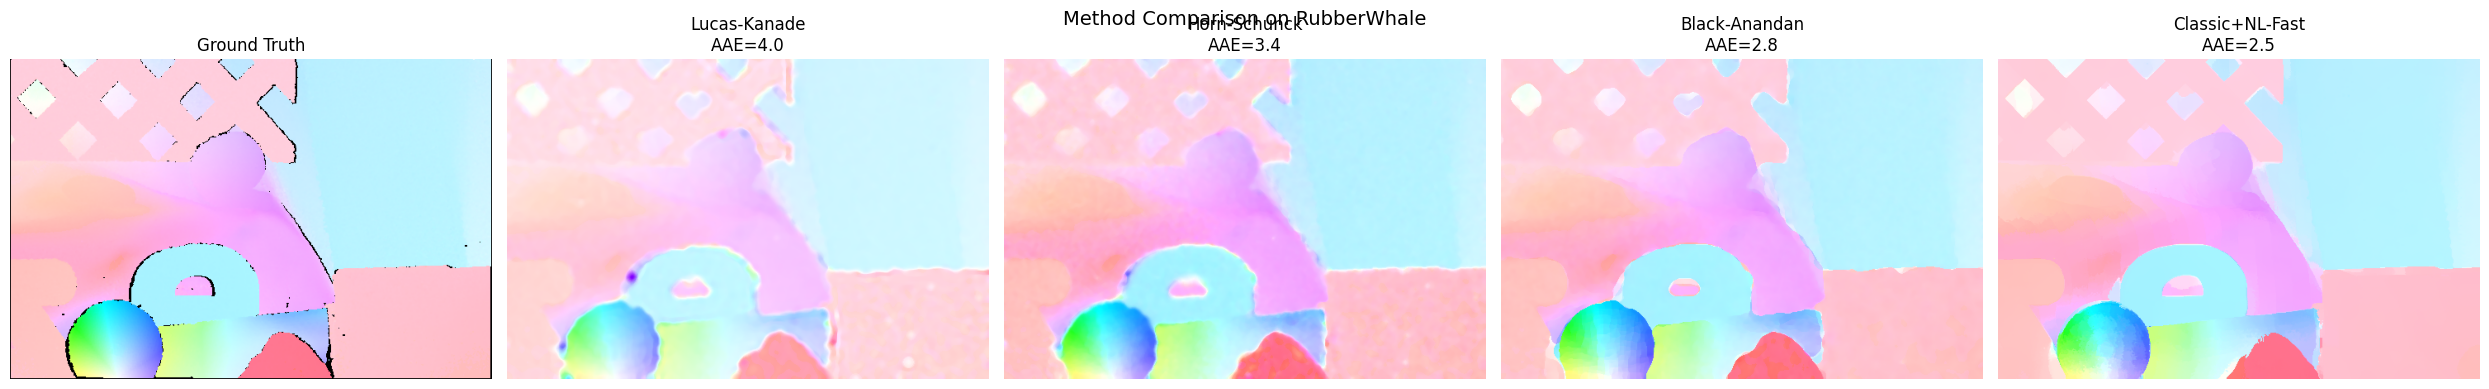

In [20]:
n = len(flows)
fig, axes = plt.subplots(1, n + 1, figsize=(5 * (n + 1), 4))

plot_flow(gt_flow, style='color', ax=axes[0])
axes[0].set_title('Ground Truth')

for i, (label, uv) in enumerate(flows.items()):
    r = results[i]
    plot_flow(uv, style='color', ax=axes[i + 1])
    axes[i + 1].set_title(f'{label}\nAAE={r["aae"]:.1f}')

plt.suptitle('Method Comparison on RubberWhale', fontsize=14)
plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated:

1. Lucas-Kanade optical flow estimation with the `'lk'` method
2. Per-pixel **reliability map** (minimum eigenvalue of the structure tensor)
3. Relationship between reliability and endpoint error
4. Effect of **window size** on accuracy and spatial resolution
5. Comparison with global variational methods (HS, BA, Classic+NL)

The reliability map is accessible via `LKOpticalFlow.reliability` after calling
`compute_flow()`. Higher reliability values indicate pixels with strong gradients
in multiple directions, where the flow estimate is well-conditioned.